# 03. Segmentation Demo (Sliding Window)

## Overview
This notebook covers the **Segmentation** process, transforming continuous EEG recordings into training samples.

### Why Segment?
1.  **Stationarity:** EEG signals are non-stationary over long periods. Short windows (~1s) are statistically more stable.
2.  **Dataset Augmentation:** Overlapping windows drastically increase the number of training samples.


In [9]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.data_processing.loader import load_bonn_data
from src.data_processing.segmentation import segment_data

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

## 1. Sliding Window Concept
We use a **Sliding Window** approach with overlap.

- **Window Size (N):** 178 timepoints (~1.025 seconds)
- **Step Size (S):** 45 timepoints
- **Overlap:** 178 - 45 = 133 timepoints (~75%)

The total number of segments per recording is calculated as: $Segments = \lfloor \frac{TotalPoints - Window}{Step} \rfloor + 1$

In [10]:
total_points = 4097
window_size = 178
step_size = 45

print(f"Total Points per Recording: {total_points}")
print(f"Window Size: {window_size}")
print(f"Step Size: {step_size} (Overlap: {window_size - step_size})")

segments_per_record = (total_points - window_size) // step_size + 1
print(f"Segments generated per recording: {segments_per_record}")

Total Points per Recording: 4097
Window Size: 178
Step Size: 45 (Overlap: 133)
Segments generated per recording: 88


## 2. Load and Segment Data
Applying the segmentation to the full dataset.

In [11]:
data_path = os.path.join('..', 'data', 'raw')
X, y = load_bonn_data(data_path)
print(f"Original Data Shape: {X.shape}")

print("Running Segmentation...")
X_seg, y_seg = segment_data(X, y, window_size=window_size, step_size=step_size)

print(f"Segmented Data Shape: {X_seg.shape}")
print(f"Segmented Labels Shape: {y_seg.shape}")
print(f"Expansion Factor: {X_seg.shape[0] / X.shape[0]:.1f}x")

Loading 100 files from Z (Class 0)...
Loading 100 files from O (Class 0)...
Loading 100 files from N (Class 0)...
Loading 100 files from F (Class 0)...
Loading 100 files from S (Class 1)...
Original Data Shape: (500, 4097)
Running Segmentation...
Segmented Data Shape: (44000, 178)
Segmented Labels Shape: (44000,)
Expansion Factor: 88.0x


## 3. Visualization: Overlapping Windows
Let's visualize how the first 3 segments are extracted from a single recording. This clearly shows the overlap.

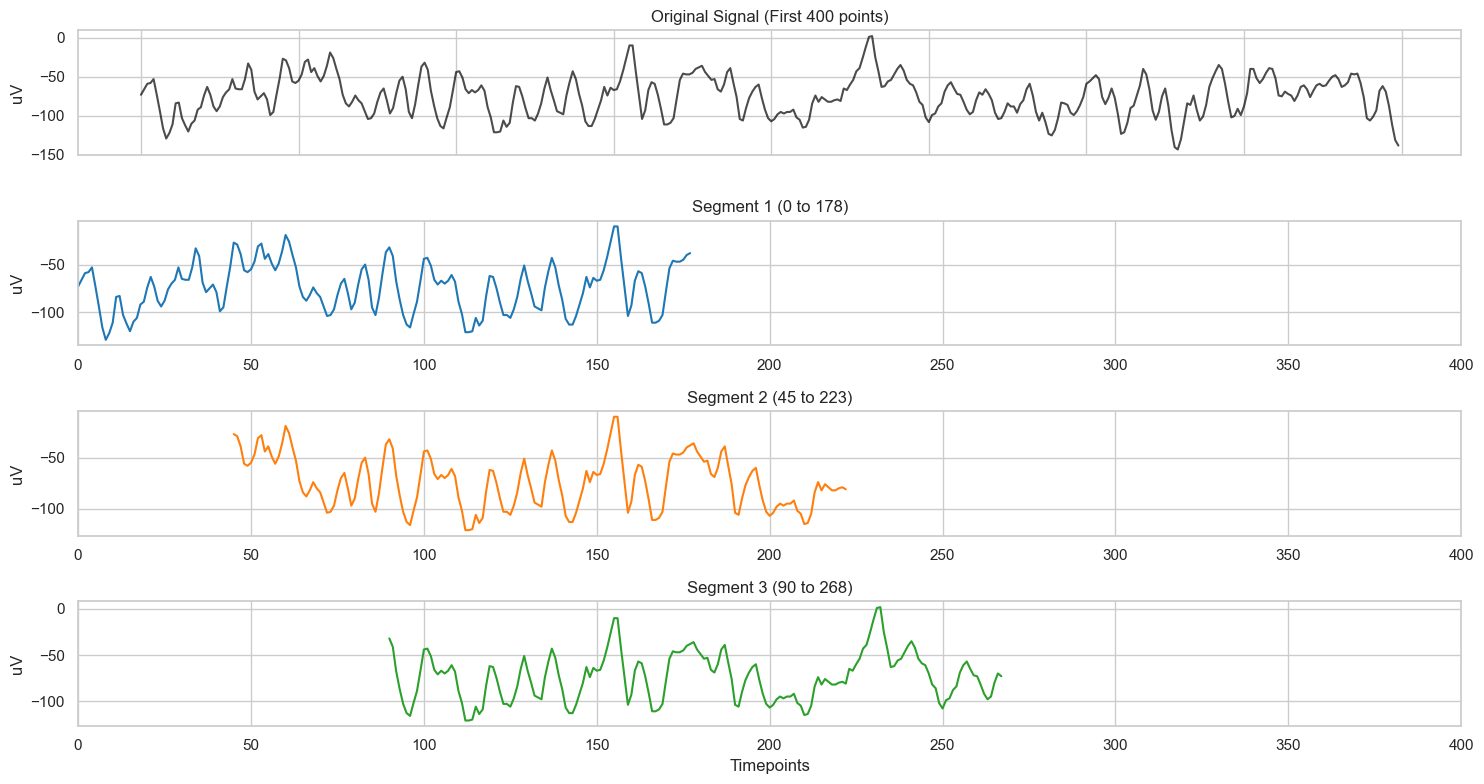

In [12]:
sample_idx = 0
original_signal = X[sample_idx]

# Manually extract first 3 segments for plotting
seg1 = original_signal[0 : window_size]
seg2 = original_signal[step_size : step_size + window_size]
seg3 = original_signal[step_size*2 : step_size*2 + window_size]

plt.figure(figsize=(15, 8))

# Plot Original Signal (partial)
plt.subplot(4, 1, 1)
plt.plot(original_signal[:400], color='black', alpha=0.7)
plt.title("Original Signal (First 400 points)")
plt.ylabel("uV")
plt.gca().axes.xaxis.set_ticklabels([]) # Hide x-labels

# Plot Segments
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
offset_y = 0 # For visualization spacing

plt.subplot(4, 1, 2)
plt.plot(np.arange(0, window_size), seg1, color=colors[0], label='Segment 1')
plt.title(f"Segment 1 (0 to {window_size})")
plt.xlim(0, 400)
plt.ylabel("uV")

plt.subplot(4, 1, 3)
plt.plot(np.arange(step_size, step_size + window_size), seg2, color=colors[1], label='Segment 2')
plt.title(f"Segment 2 ({step_size} to {step_size + window_size})")
plt.xlim(0, 400)
plt.ylabel("uV")

plt.subplot(4, 1, 4)
plt.plot(np.arange(step_size*2, step_size*2 + window_size), seg3, color=colors[2], label='Segment 3')
plt.title(f"Segment 3 ({step_size*2} to {step_size*2 + window_size})")
plt.xlim(0, 400)
plt.xlabel("Timepoints")
plt.ylabel("uV")

plt.tight_layout()
plt.show()